<a href="https://colab.research.google.com/github/Yashzope/EDA_PracT/blob/main/edaPracT5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import log_loss
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Poisson as psn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.api import Holt
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import os
print(os.getcwd())
os.chdir('/content/drive/MyDrive/AAS_data')
os.getcwd()

/content


'/content/drive/MyDrive/AAS_data'

In [2]:
df = pd.read_excel('/content/drive/MyDrive/AAS_data/CaseStudy.xlsx')

In [3]:
df.shape

(3000, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     3000 non-null   int64 
 1   Income  3000 non-null   int64 
 2   Gender  3000 non-null   object
 3   Region  3000 non-null   object
 4   Target  3000 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 117.3+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

,0
Age,int64
Income,int64
Gender,object
Region,object
Target,int64


In [7]:
df.head()

,Age,Income,Gender,Region,Target
0,58,51722,Female,South,1
1,48,98373,Male,South,1
2,34,51536,Male,South,1
3,62,62768,Male,South,1
4,27,83132,Female,South,0


<Axes: >

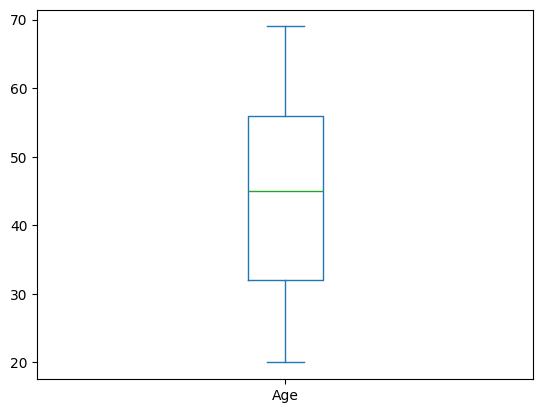

In [8]:
df['Age'].plot(kind='box')

<Axes: >

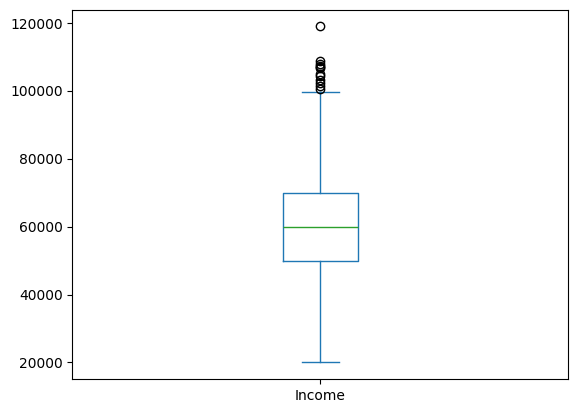

In [9]:
df['Income'].plot(kind='box')

In [10]:
df['Gender'].value_counts()

,count
Gender,
Female,1507
Male,1493


In [11]:
df['Region'].value_counts()

,count
Region,
North,1222
South,1103
West,675


In [12]:
pd.crosstab(df['Region'],df['Target'])

Target,0,1
Region,,
North,161,1061
South,232,871
West,306,369


In [13]:
pd.crosstab(df['Gender'],df['Target'])

Target,0,1
Gender,,
Female,434,1073
Male,265,1228


In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
le = LabelEncoder()

In [16]:
df.head()

,Age,Income,Gender,Region,Target
0,58,51722,Female,South,1
1,48,98373,Male,South,1
2,34,51536,Male,South,1
3,62,62768,Male,South,1
4,27,83132,Female,South,0


In [17]:
df['Gender'] = le.fit_transform(df['Gender'])

In [18]:
df.head()

,Age,Income,Gender,Region,Target
0,58,51722,0,South,1
1,48,98373,1,South,1
2,34,51536,1,South,1
3,62,62768,1,South,1
4,27,83132,0,South,0


In [19]:
pd.get_dummies(df,columns=['Region'],drop_first=True)

,Age,Income,Gender,Target,Region_South,Region_West
0,58,51722,0,1,True,False
1,48,98373,1,1,True,False
2,34,51536,1,1,True,False
3,62,62768,1,1,True,False
4,27,83132,0,0,True,False
...,...,...,...,...,...,...
2995,65,36079,1,1,False,False
2996,23,66310,1,0,True,False
2997,64,51331,0,0,True,False
2998,39,73217,1,1,False,True


In [20]:
df = pd.get_dummies(df,columns=['Region'],drop_first=True,dtype=int)

In [21]:
df.head()

,Age,Income,Gender,Target,Region_South,Region_West
0,58,51722,0,1,1,0
1,48,98373,1,1,1,0
2,34,51536,1,1,1,0
3,62,62768,1,1,1,0
4,27,83132,0,0,1,0


In [22]:
df['Income'].min()

20000

In [23]:
df['Income'].median()

59933.0

In [24]:
df['Income'].max()

118894

In [25]:
#outliers

In [26]:
Q1 = df['Income'].quantile(0.25)
Q2 = df['Income'].quantile(0.50)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

In [27]:
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

In [28]:
(df['Income'] < lower).value_counts()

,count
Income,
False,3000


In [29]:
(df['Income'] > upper).value_counts()

,count
Income,
False,2988
True,12


In [30]:
np.where(df['Income'] > upper)

(array([ 125,  467,  545,  815, 1016, 1031, 1311, 1405, 1751, 2226, 2492,
        2557]),)

In [31]:
df.drop(np.where(df['Income'] > upper)[0])

,Age,Income,Gender,Target,Region_South,Region_West
0,58,51722,0,1,1,0
1,48,98373,1,1,1,0
2,34,51536,1,1,1,0
3,62,62768,1,1,1,0
4,27,83132,0,0,1,0
...,...,...,...,...,...,...
2995,65,36079,1,1,0,0
2996,23,66310,1,0,1,0
2997,64,51331,0,0,1,0
2998,39,73217,1,1,0,1


In [32]:
df.corr()

,Age,Income,Gender,Target,Region_South,Region_West
Age,1.000000,-0.013766,-0.021939,0.256301,0.014762,0.013074
Income,-0.013766,1.000000,-0.024468,-0.018859,-0.019486,-0.015269
Gender,-0.021939,-0.024468,1.000000,0.130686,-0.004046,-0.009459
Target,0.256301,-0.018859,0.130686,1.000000,0.040881,-0.280831
Region_South,0.014762,-0.019486,-0.004046,0.040881,1.000000,-0.410861
Region_West,0.013074,-0.015269,-0.009459,-0.280831,-0.410861,1.000000


In [33]:
df = df.drop(np.where(df['Income'] > upper)[0])

In [34]:
df.head()

,Age,Income,Gender,Target,Region_South,Region_West
0,58,51722,0,1,1,0
1,48,98373,1,1,1,0
2,34,51536,1,1,1,0
3,62,62768,1,1,1,0
4,27,83132,0,0,1,0


In [35]:
(df['Income'] > upper).value_counts()

,count
Income,
False,2988


In [36]:
#no outliers now

In [37]:
df.corr()

,Age,Income,Gender,Target,Region_South,Region_West
Age,1.000000,-0.009652,-0.022357,0.255494,0.012813,0.014504
Income,-0.009652,1.000000,-0.029066,-0.016118,-0.021058,-0.019437
Gender,-0.022357,-0.029066,1.000000,0.132143,-0.003739,-0.010392
Target,0.255494,-0.016118,0.132143,1.000000,0.041720,-0.280809
Region_South,0.012813,-0.021058,-0.003739,0.041720,1.000000,-0.410174
Region_West,0.014504,-0.019437,-0.010392,-0.280809,-0.410174,1.000000


MACHINE LEARNING MODELS


In [38]:
x = df.drop('Target',axis = 1)

In [39]:
x.head()

,Age,Income,Gender,Region_South,Region_West
0,58,51722,0,1,0
1,48,98373,1,1,0
2,34,51536,1,1,0
3,62,62768,1,1,0
4,27,83132,0,1,0


In [40]:
y = df['Target']

In [41]:
y.head()

,Target
0,1
1,1
2,1
3,1
4,0


In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [44]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2390, 5)
(598, 5)
(2390,)
(598,)


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()

In [47]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [48]:
#done with standardization now logistic regression

Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
model = LogisticRegression()

In [51]:
model.fit(x_train,y_train)

LogisticRegression()

In [52]:
model.coef_

array([[ 0.82148409, -0.02760105,  0.41253548, -0.28317667, -0.8208514 ]])

In [53]:
pd.DataFrame({'Features':x.columns,
              'Coefficient':model.coef_[0]})

,Features,Coefficient
0,Age,0.821484
1,Income,-0.027601
2,Gender,0.412535
3,Region_South,-0.283177
4,Region_West,-0.820851


In [54]:
model.intercept_

array([1.52300232])

In [55]:
y_pred = model.predict(x_test)

In [56]:
pd.DataFrame({'Actual':y_test,
              'Predicted':y_pred}).head()

,Actual,Predicted
1648,1,1
730,1,1
2867,1,1
1526,0,1
2935,1,1


In [57]:
model.predict_proba(x_test)[:5]

array([[0.25593304, 0.74406696],
       [0.10522589, 0.89477411],
       [0.24097225, 0.75902775],
       [0.35989776, 0.64010224],
       [0.26539449, 0.73460551]])

different approchusing stats model

In [58]:
import statsmodels.api as sm
x_train = sm.add_constant(x_train,prepend=False)

In [59]:
model = sm.Logit(y_train,x_train).fit()

Optimization terminated successfully.
         Current function value: 0.442395
         Iterations 6


In [60]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:                 2390
Model:                          Logit   Df Residuals:                     2384
Method:                           MLE   Df Model:                            5
Date:                Wed, 24 Jun 2026   Pseudo R-squ.:                  0.1806
Time:                        03:39:42   Log-Likelihood:                -1057.3
converged:                       True   LL-Null:                       -1290.4
Covariance Type:            nonrobust   LLR p-value:                 1.550e-98
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8250      0.060     13.793      0.000       0.708       0.942
x2            -0.0278      0.054     -0.514      0.607      -0.134       0.078
x3             0.4142      0.056      7.438      0.0

In [61]:
df.head()

,Age,Income,Gender,Target,Region_South,Region_West
0,58,51722,0,1,1,0
1,48,98373,1,1,1,0
2,34,51536,1,1,1,0
3,62,62768,1,1,1,0
4,27,83132,0,0,1,0


In [62]:
#y_prob = model.predict(x_test)

In [63]:
x_test = sm.add_constant(x_test,prepend=False)

In [64]:
y_prob = model.predict(x_test)

In [65]:
y_pred = (y_prob > 0.5).astype(int)

In [66]:
from sklearn.metrics import confusion_matrix

In [67]:
cm = confusion_matrix(y_test,y_pred)

In [68]:
cm

array([[ 38, 106],
       [ 27, 427]])

In [69]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7775919732441472

In [70]:
from sklearn.metrics import precision_score
precision_score(y_test,y_pred)

0.801125703564728

In [71]:
from sklearn.metrics import recall_score
recall_score(y_test,y_pred)

0.9405286343612335